<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/RNN_Weekday_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

np.random.seed(42)
tf.random.set_seed(42)

#Step 2: Create Dataset

In [2]:
days = [

    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"

]

window_size = 3

X = []
y = []

for i in range(len(days)):

    sequence = []

    for j in range(window_size):

        sequence.append(
            days[(i+j)%7]
        )

    target = days[(i+window_size)%7]

    X.append(sequence)

    y.append(target)

print(X)

print(y)

[['Monday', 'Tuesday', 'Wednesday'], ['Tuesday', 'Wednesday', 'Thursday'], ['Wednesday', 'Thursday', 'Friday'], ['Thursday', 'Friday', 'Saturday'], ['Friday', 'Saturday', 'Sunday'], ['Saturday', 'Sunday', 'Monday'], ['Sunday', 'Monday', 'Tuesday']]
['Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday']


#Step 3: Encode Days

In [3]:
day_to_int = {

    day:index

    for index,day in enumerate(days)

}

int_to_day = {

    index:day

    for index,day in enumerate(days)

}

print(day_to_int)

{'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}


#Step 4: Convert Dataset

In [4]:
X_encoded = []

for seq in X:

    X_encoded.append(

        [day_to_int[d] for d in seq]

    )

X_encoded = np.array(X_encoded)

y_encoded = np.array(

    [day_to_int[d] for d in y]

)

print(X_encoded)

[[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]
 [4 5 6]
 [5 6 0]
 [6 0 1]]


#Step 5: Build RNN Model

In [5]:
vocab_size = len(days)

model = Sequential([

    Embedding(

        input_dim=vocab_size,

        output_dim=8,

        input_length=window_size

    ),

    SimpleRNN(32),

    Dense(

        vocab_size,

        activation="softmax"

    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


#Step 6: Compile

In [6]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

#Step 7: Train

In [7]:
history = model.fit(

    X_encoded,

    y_encoded,

    epochs=500,

    verbose=0
)

#Step 8: Predict

In [8]:
test = [

    "Friday",

    "Saturday",

    "Sunday"

]

sequence = np.array([

    [day_to_int[d] for d in test]

])

prediction = model.predict(

    sequence,

    verbose=0
)

index = np.argmax(prediction)

print(

    "Predicted Day :",

    int_to_day[index]

)

Predicted Day : Monday


#Step 9: Test Multiple Sequences

In [9]:
tests = [

    ["Monday","Tuesday","Wednesday"],

    ["Tuesday","Wednesday","Thursday"],

    ["Wednesday","Thursday","Friday"],

    ["Thursday","Friday","Saturday"],

    ["Friday","Saturday","Sunday"]

]

print("Weekday Predictions\n")

for sample in tests:

    seq = np.array([

        [day_to_int[d] for d in sample]

    ])

    prediction = model.predict(

        seq,

        verbose=0
    )

    index = np.argmax(prediction)

    print(

        sample,

        "->",

        int_to_day[index]

    )

Weekday Predictions

['Monday', 'Tuesday', 'Wednesday'] -> Thursday
['Tuesday', 'Wednesday', 'Thursday'] -> Friday
['Wednesday', 'Thursday', 'Friday'] -> Saturday
['Thursday', 'Friday', 'Saturday'] -> Sunday
['Friday', 'Saturday', 'Sunday'] -> Monday


#Step 10: Top-3 Predictions

In [10]:
test = [

    "Friday",

    "Saturday",

    "Sunday"

]

sequence = np.array([

    [day_to_int[d] for d in test]

])

prediction = model.predict(sequence, verbose=0)

top3 = np.argsort(prediction[0])[-3:][::-1]

print("Top 3 Predictions\n")

for idx in top3:

    print(

        int_to_day[idx],

        ":",

        round(prediction[0][idx]*100,2),

        "%"

    )

Top 3 Predictions

Monday : 99.78 %
Thursday : 0.07 %
Friday : 0.05 %


#Step 11: Plot Accuracy

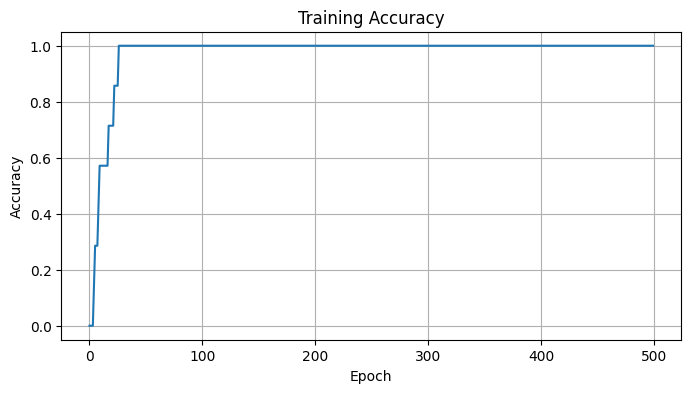

In [12]:
plt.figure(figsize=(8,4))

plt.plot(history.history["accuracy"])

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

#Step 12: Plot Loss

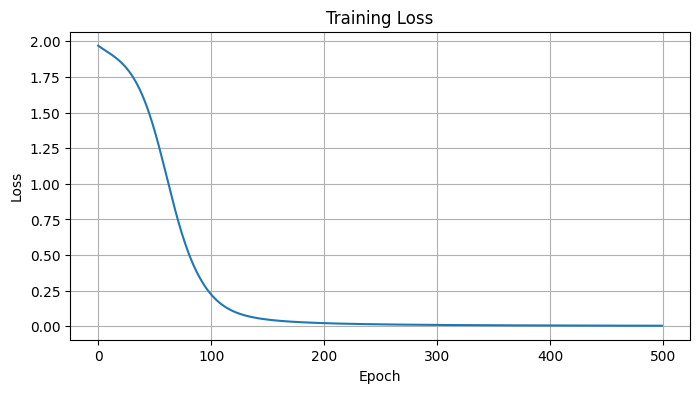

In [13]:
plt.figure(figsize=(8,4))

plt.plot(history.history["loss"])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()